In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==============================================================================
# DATA INGESTION, CACHING & UNIVERSE DOCUMENTATION
# ==============================================================================
print("="*80)
print("PHASE 1: UNIVERSE DEFINITION & DATA INGESTION")
print("="*80)

# 1. Define the Asset Universe with Metadata for Documentation
asset_info = {
    'SPY':   {'Class': 'US Large Cap',      'Name': 'SPDR S&P 500 ETF Trust'},
    'MDY':   {'Class': 'US Mid Cap',        'Name': 'SPDR S&P MidCap 400 ETF Trust'},
    'IWM':   {'Class': 'US Small Cap',      'Name': 'iShares Russell 2000 ETF'},
    'EFA':   {'Class': 'Intl Developed',    'Name': 'iShares MSCI EAFE ETF'},
    'EEM':   {'Class': 'Emerging Markets',  'Name': 'iShares MSCI Emerging Markets ETF'},
    'AGG':   {'Class': 'US Aggregate Bond', 'Name': 'iShares Core US Aggregate Bond ETF'},
    'TLT':   {'Class': 'US Long Treasury',  'Name': 'iShares 20+ Year Treasury Bond ETF'},
    'VNQ':   {'Class': 'US Real Estate',    'Name': 'Vanguard Real Estate Index Fund ETF'},
    'GLD':   {'Class': 'Gold',              'Name': 'SPDR Gold Shares'},
    'PCRIX': {'Class': 'Commodities Proxy', 'Name': 'PIMCO Commodity Real Return Strategy Fund'},
    'VWEHX': {'Class': 'High Yield Proxy',  'Name': 'Vanguard High-Yield Corporate Fund'},
    'VFISX': {'Class': 'Risk-Free Proxy',   'Name': 'Vanguard Short-Term Treasury Fund'}
}

tickers = list(asset_info.keys())

# Print the Universe Documentation
print(f"{'Ticker':<8} | {'Asset Class':<20} | {'Instrument / Fund Name'}")
print("-" * 80)
for t, info in asset_info.items():
    print(f"{t:<8} | {info['Class']:<20} | {info['Name']}")
print("-" * 80)

# 2. Local Caching Logic (Saves time and prevents API rate limits)
csv_filename = "Portfolio Asset Price Dataset.csv"
file_path = f"Data/{csv_filename}"

os.makedirs("Data", exist_ok=True)

if os.path.exists(file_path):
    print(f"\n[INFO] Loading historical data locally from '{csv_filename}'...")
    data = pd.read_csv(file_path, index_col=0, parse_dates=True)
else:
    print("\n[INFO] Downloading data from Yahoo Finance...")
    # GLD launched Nov 18, 2004. We start Dec 1 for clean monthly resampling.
    data = yf.download(tickers, start="2004-12-01", end="2026-05-10", progress=False)['Close']
    data = data.ffill().dropna()
    data.to_csv(f"Data/{csv_filename}")
    print(f"[SUCCESS] Data downloaded and saved locally to '{csv_filename}'")

# 3. Monthly Resampling & Setup
monthly_data = data.resample('ME').last()
monthly_returns = monthly_data.pct_change().dropna()

rf_monthly = monthly_returns['VFISX']
risky_monthly = monthly_returns.drop(columns=['VFISX'])
excess_returns = risky_monthly.sub(rf_monthly, axis=0)
assets = risky_monthly.columns
n_assets = len(assets)

print(f"\nTimeframe Coverage: {len(monthly_returns)} Full Months")
print(f"Start Date:         {monthly_returns.index[0].strftime('%B %Y')}")
print(f"End Date:           {monthly_returns.index[-1].strftime('%B %Y')}")

PHASE 1: UNIVERSE DEFINITION & DATA INGESTION
Ticker   | Asset Class          | Instrument / Fund Name
--------------------------------------------------------------------------------
SPY      | US Large Cap         | SPDR S&P 500 ETF Trust
MDY      | US Mid Cap           | SPDR S&P MidCap 400 ETF Trust
IWM      | US Small Cap         | iShares Russell 2000 ETF
EFA      | Intl Developed       | iShares MSCI EAFE ETF
EEM      | Emerging Markets     | iShares MSCI Emerging Markets ETF
AGG      | US Aggregate Bond    | iShares Core US Aggregate Bond ETF
TLT      | US Long Treasury     | iShares 20+ Year Treasury Bond ETF
VNQ      | US Real Estate       | Vanguard Real Estate Index Fund ETF
GLD      | Gold                 | SPDR Gold Shares
PCRIX    | Commodities Proxy    | PIMCO Commodity Real Return Strategy Fund
VWEHX    | High Yield Proxy     | Vanguard High-Yield Corporate Fund
VFISX    | Risk-Free Proxy      | Vanguard Short-Term Treasury Fund
----------------------------------------


PHASE 2: THE 4 BASELINE STRATEGY CONFIGURATIONS
Global Walk-Forward Parameters:
- Lookback Window       : 36 Months (Rolling)
- Rebalancing Frequency : Monthly
- Annual Target Vol     : 10.0%

1. Constant Rebalanced Asset Allocation (1/N)
- Optimization Target : None (Static Heuristic)
- Long/Short Bound    : w_i in [0.0, 1.0] (Strictly Long-Only)
- Leverage Constraint : Sum(w) = 1.0 (Fully Invested)

2. Inverse Volatility Risk Parity (Unleveraged)
- Optimization Target : Equalize risk assuming zero asset correlation
- Long/Short Bound    : w_i in [0.0, 1.0] (Strictly Long-Only)
- Leverage Constraint : Sum(w) = 1.0 (Fully Invested)

3. Risk Parity (Equalized Risk Contribution)
- Optimization Target : Equalize exact Marginal Contribution to Risk (MCTR) using Covariance
- Long/Short Bound    : w_i in [0.0, 1.0] (Strictly Long-Only)
- Leverage Constraint : Sum(w) = 1.0 (Fully Invested)

4. Mean-Variance Optimization (Lecture Notes MVO)
- Optimization Target : Maximize Expected Return sub

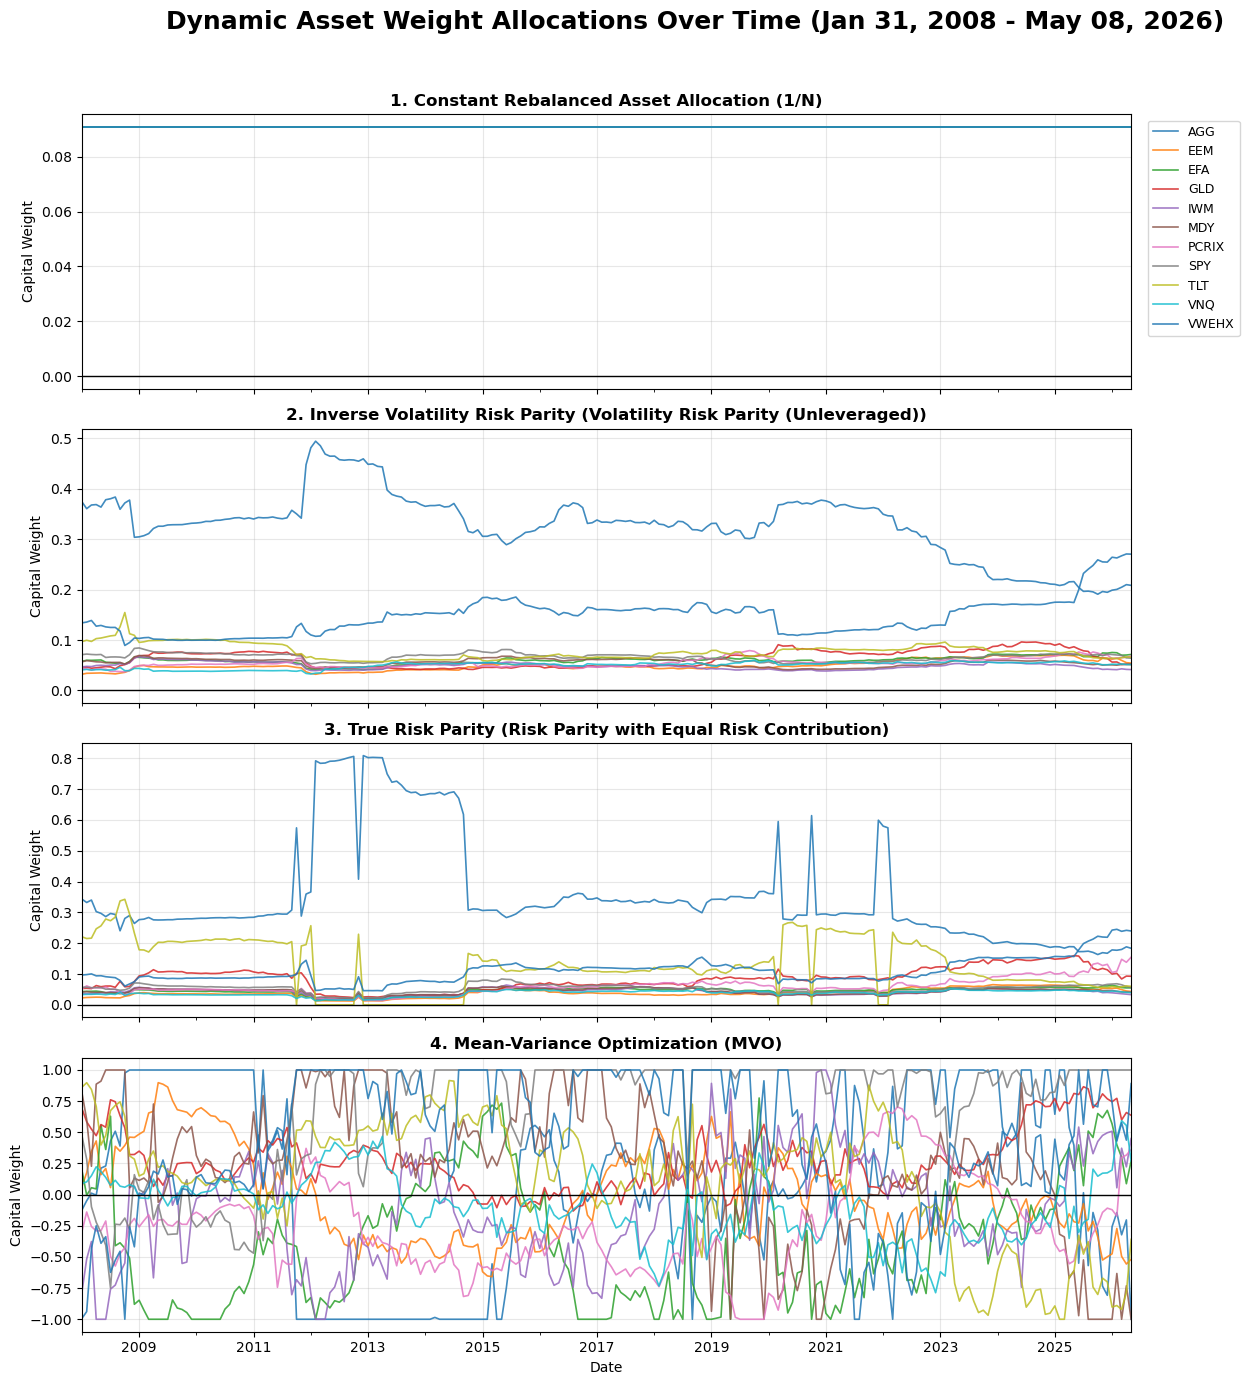

Rendering Ex-Post Risk Contribution Chart...
[SUCCESS] Chart saved as 'Chart_Phase_5_Risk_Decomposition.png'


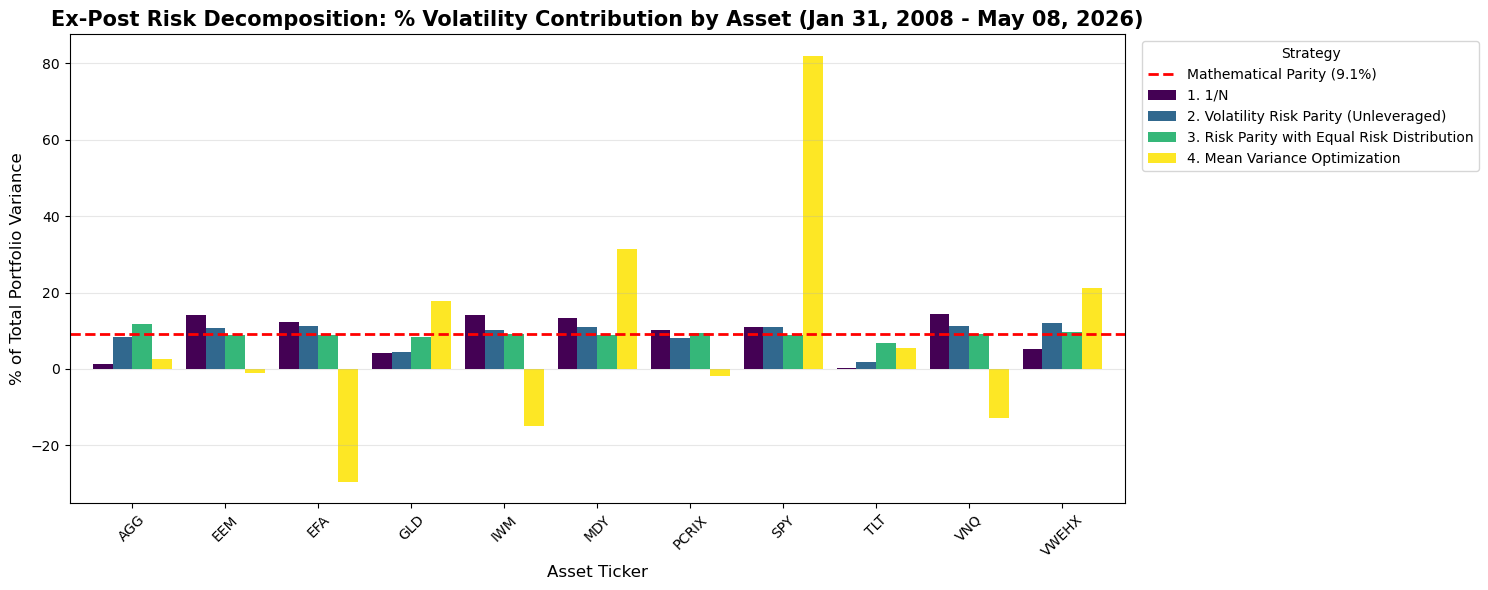


EX-POST RISK CONTRIBUTION DECOMPOSITION MATRIX (%) [Jan 31, 2008 - May 08, 2026]
        1. 1/N 2. Volatility Risk Parity (Unleveraged) 3. Risk Parity with Equal Risk Distribution 4. Mean Variance Optimization
Ticker                                                                                                                          
AGG      1.29%                                   8.23%                                      11.82%                         2.53%
EEM     14.20%                                  10.72%                                       8.92%                        -1.16%
EFA     12.35%                                  11.23%                                       8.96%                       -29.59%
GLD      4.16%                                   4.39%                                       8.29%                        17.87%
IWM     13.99%                                  10.24%                                       9.10%                       -15.06%
MDY     13.25% 

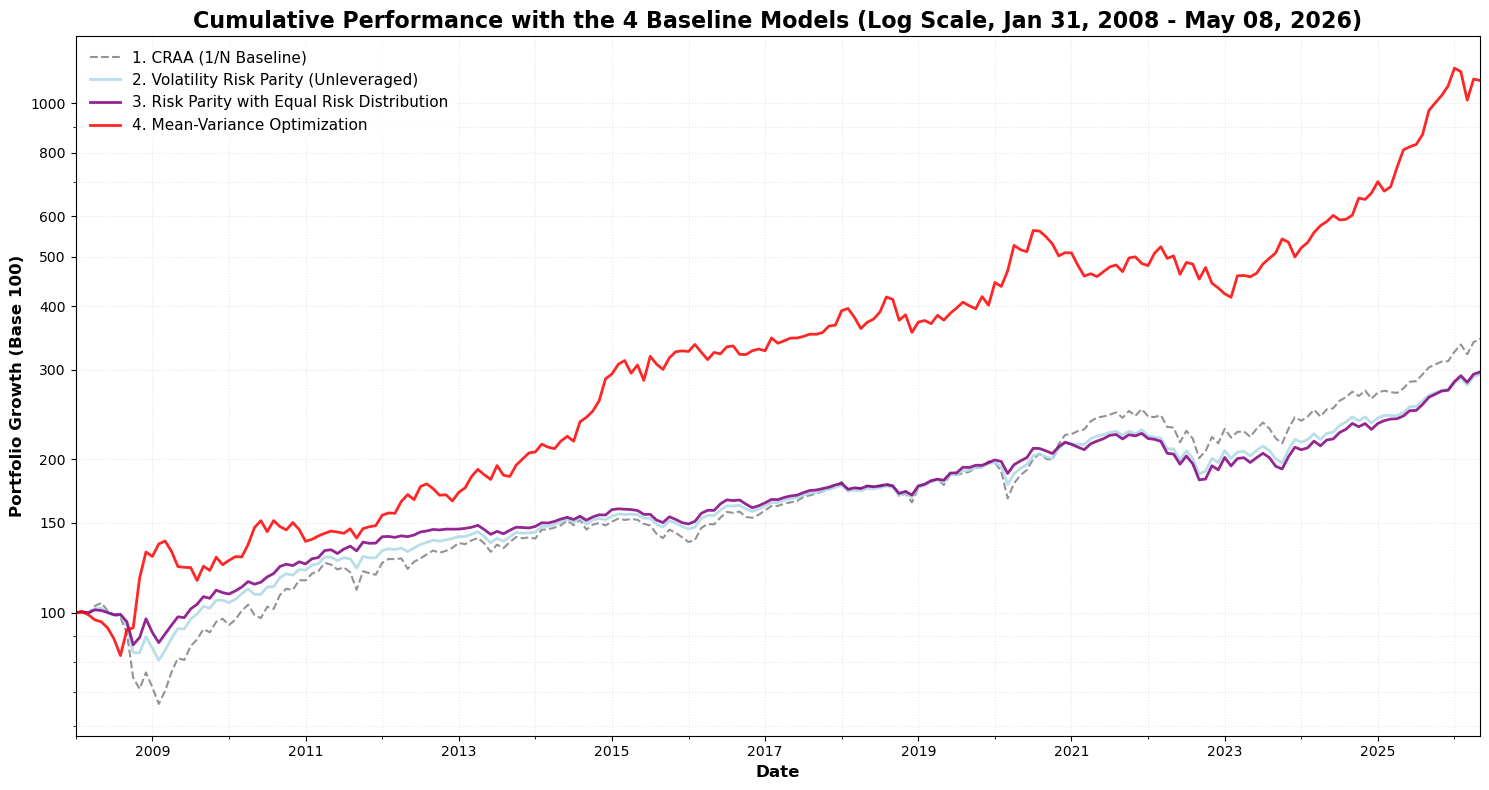

In [3]:
# ==============================================================================
# STRATEGY DEFINITIONS & MATHEMATICAL CONSTRAINTS
# ==============================================================================
import os
import scipy.optimize as sco
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("PHASE 2: THE 4 BASELINE STRATEGY CONFIGURATIONS")
print("="*80)

win = 36 # 36-Month Rolling Training Window
ann_vol_tgt = 0.1 # 10% Annualized Volatility Target
mo_vol_tgt = ann_vol_tgt / np.sqrt(12) 

print(f"Global Walk-Forward Parameters:")
print(f"- Lookback Window       : {win} Months (Rolling)")
print(f"- Rebalancing Frequency : Monthly")
print(f"- Annual Target Vol     : {ann_vol_tgt*100}%\n")

print("1. Constant Rebalanced Asset Allocation (1/N)")
print("- Optimization Target : None (Static Heuristic)")
print("- Long/Short Bound    : w_i in [0.0, 1.0] (Strictly Long-Only)")
print("- Leverage Constraint : Sum(w) = 1.0 (Fully Invested)\n")

print("2. Inverse Volatility Risk Parity (Unleveraged)")
print("- Optimization Target : Equalize risk assuming zero asset correlation")
print("- Long/Short Bound    : w_i in [0.0, 1.0] (Strictly Long-Only)")
print("- Leverage Constraint : Sum(w) = 1.0 (Fully Invested)\n")

print("3. Risk Parity (Equalized Risk Contribution)")
print("- Optimization Target : Equalize exact Marginal Contribution to Risk (MCTR) using Covariance")
print("- Long/Short Bound    : w_i in [0.0, 1.0] (Strictly Long-Only)")
print("- Leverage Constraint : Sum(w) = 1.0 (Fully Invested)\n")

print("4. Mean-Variance Optimization (Lecture Notes MVO)")
print("- Optimization Target : Maximize Expected Return subject to 8% annualized Volatility Cap")
print("- Long/Short Bound    : w_i in [-1.0, 1.0] (Allows Short Selling / Hedging)")
print("- Leverage Constraint : Sum(w) = 1.0 (Net Fully Invested)\n")

# ==============================================================================
# THE WALK-FORWARD OPTIMIZATION ENGINE
# ==============================================================================
oos_dates = excess_returns.index[win:]

print("="*80)
print(f"PHASE 3: EXECUTING ROLLING OPTIMIZATIONS (Starts {oos_dates[0].strftime('%b %Y')})")
print("="*80)

risky_assets = excess_returns.columns
n_assets = len(risky_assets)

# Tracking DataFrames for Weights (All locked to the 11 Risky Assets)
weights = {
    '1/N': pd.DataFrame(index=oos_dates, columns=risky_assets, dtype=float),
    'VRP_Unlev': pd.DataFrame(index=oos_dates, columns=risky_assets, dtype=float),
    'ERC': pd.DataFrame(index=oos_dates, columns=risky_assets, dtype=float),
    'MVO': pd.DataFrame(index=oos_dates, columns=risky_assets, dtype=float)
}

def erc_objective(w, cov_matrix):
    port_var = np.dot(w.T, np.dot(cov_matrix, w))
    marginal_contrib = np.dot(cov_matrix, w)
    risk_contrib = w * marginal_contrib
    target_risk = port_var / n_assets
    return np.sum(np.square(risk_contrib - target_risk)) * 1e9

for t in oos_dates:
    # CRITICAL FIX: .iloc[-win:] ensures month 't' data is included for month 't+1' allocation
    train_rets = excess_returns.loc[:t].iloc[-win:]
    
    mu = train_rets.mean().values
    cov = train_rets.cov().values
    inv_vol = 1.0 / train_rets.std().values
    init_w = np.array([1.0/n_assets]*n_assets)
    
    # 1. 1/N
    weights['1/N'].loc[t] = 1.0 / n_assets
    
    # 2. Volatility Risk Parity (Unleveraged)
    w_afp = inv_vol / np.sum(inv_vol)
    weights['VRP_Unlev'].loc[t] = w_afp
    
    # 3. ERC
    erc_cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    erc_bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    opt_erc = sco.minimize(erc_objective, init_w, args=(cov,), method='SLSQP', bounds=erc_bounds, constraints=erc_cons)
    weights['ERC'].loc[t] = opt_erc.x if opt_erc.success else w_afp
    
    # 4. MVO (Restored to original 11-asset long-short framework)
    def mvo_obj(w): return -np.dot(mu, w)
    mvo_cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq', 'fun': lambda w: (mo_vol_tgt**2) - np.dot(w.T, np.dot(cov, w))} 
    ]
    mvo_bounds = tuple((-1.0, 1.0) for _ in range(n_assets))
    opt_mvo = sco.minimize(mvo_obj, init_w, method='SLSQP', bounds=mvo_bounds, constraints=mvo_cons)
    weights['MVO'].loc[t] = opt_mvo.x if opt_mvo.success else init_w

print("[SUCCESS] Walk-forward complete.")

# ------------------------------------------------------------------------------
# DYNAMIC DATE EXTRACTION FOR CHARTS (Anchored to Inception)
# ------------------------------------------------------------------------------
inception_date = oos_dates[0]
eval_start_str = inception_date.strftime('%b %d, %Y')

actual_last_date = data.index[-1] 
eval_end_date = weights['1/N'].index[-1]

if eval_end_date > actual_last_date:
    eval_end_str = actual_last_date.strftime('%b %d, %Y')
else:
    eval_end_str = eval_end_date.strftime('%b %d, %Y')

date_label = f"{eval_start_str} - {eval_end_str}"
print(f"\n[INFO] Dynamic Evaluation Period Locked: {date_label}")

# ==============================================================================
# EXPORT BASELINE WEIGHTS TO DATA FOLDER
# ==============================================================================
print("\nExporting baseline weights to 'Data' folder for ML integration...")

from pathlib import Path
data_folder = Path("Data")
data_folder.mkdir(parents=True, exist_ok=True)

weights['1/N'].to_csv(data_folder / 'baseline_weights_1_N.csv')
weights['VRP_Unlev'].to_csv(data_folder / 'baseline_weights_VRP.csv')
weights['ERC'].to_csv(data_folder / 'baseline_weights_ERC.csv')
weights['MVO'].to_csv(data_folder / 'baseline_weights_MVO.csv')

print("[SUCCESS] All 4 baseline weight matrices successfully saved to 'Data/'.")

# ==============================================================================
# VISUALIZING WEIGHT ALLOCATIONS OVER TIME
# ==============================================================================
print("\nRendering Weight Allocation Charts...")

fig, axes = plt.subplots(4, 1, figsize=(14, 15), sharex=True)
fig.suptitle(f"Dynamic Asset Weight Allocations Over Time ({date_label})", fontsize=18, fontweight='bold', y=0.92)

titles = [
    "1. Constant Rebalanced Asset Allocation (1/N)",
    "2. Inverse Volatility Risk Parity (Volatility Risk Parity (Unleveraged))",
    "3. True Risk Parity (Risk Parity with Equal Risk Contribution)",
    "4. Mean-Variance Optimization (MVO)"
]

keys = ['1/N', 'VRP_Unlev', 'ERC', 'MVO']

for i, ax in enumerate(axes):
    df = weights[keys[i]].dropna()
    df.plot(ax=ax, linewidth=1.2, alpha=0.85)
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_ylabel("Capital Weight", fontsize=10)
    ax.grid(True, alpha=0.3)
    
    ax.axhline(0, color='black', linewidth=1)
    
    if i == 0: 
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
    else:
        ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.9, 0.9])
plt.show()

# ==============================================================================
# EX-POST RISK DECOMPOSITION
# ==============================================================================
print("Rendering Ex-Post Risk Contribution Chart...")

aligned_excess = excess_returns.loc[oos_dates]

def get_risk_contribution(weights_df, returns_df):
    avg_w = weights_df.mean()
    realized_cov = returns_df.cov()
    port_var = np.dot(avg_w.T, np.dot(realized_cov, avg_w))
    marginal_contrib = np.dot(realized_cov, avg_w)
    component_contrib = avg_w * marginal_contrib
    pct_contrib = (component_contrib / port_var) * 100
    return pct_contrib

risk_contribs = pd.DataFrame({
    '1. 1/N': get_risk_contribution(weights['1/N'].shift(1).dropna(), aligned_excess),
    '2. Volatility Risk Parity (Unleveraged)': get_risk_contribution(weights['VRP_Unlev'].shift(1).dropna(), aligned_excess),
    '3. Risk Parity with Equal Risk Distribution': get_risk_contribution(weights['ERC'].shift(1).dropna(), aligned_excess),
    '4. Mean Variance Optimization': get_risk_contribution(weights['MVO'].shift(1).dropna(), aligned_excess)
})

plt.figure(figsize=(15, 6))
risk_contribs.plot(kind='bar', width=0.85, ax=plt.gca(), colormap='viridis')

plt.axhline(100 / n_assets, color='red', linestyle='--', linewidth=2, label=f'Mathematical Parity ({100/n_assets:.1f}%)')

plt.title(f"Ex-Post Risk Decomposition: % Volatility Contribution by Asset ({date_label})", fontsize=15, fontweight='bold')
plt.ylabel("% of Total Portfolio Variance", fontsize=12)
plt.xlabel("Asset Ticker", fontsize=12)
plt.legend(title="Strategy", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('Chart_Phase_5_Risk_Decomposition.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Chart saved as 'Chart_Phase_5_Risk_Decomposition.png'")
plt.show()

# ==============================================================================
# PRINT RISK DECOMPOSITION TABLE
# ==============================================================================
print("\n" + "="*95)
print(f"EX-POST RISK CONTRIBUTION DECOMPOSITION MATRIX (%) [{date_label}]")
print("="*95)

risk_table_formatted = risk_contribs.map(lambda x: f"{x:.2f}%")
print(risk_table_formatted.to_string())

# ==============================================================================
# CUMULATIVE RETURNS & PERFORMANCE TEAR SHEET
# ==============================================================================
print("\n" + "="*80)
print("PHASE 6: INSTITUTIONAL PERFORMANCE TEAR SHEET & EQUITY CURVES")
print("="*80)

# 1. Align Returns and Calculate Portfolio Performance
aligned_excess = excess_returns.loc[oos_dates]
aligned_rf = rf_monthly.loc[oos_dates]

aligned_raw_risky = aligned_excess.add(aligned_rf, axis=0)
aligned_raw_all = aligned_raw_risky.copy()
aligned_raw_all['VFISX'] = aligned_rf

aligned_excess_all = aligned_excess.copy()
aligned_excess_all['VFISX'] = 0.0

def get_port_returns(weight_df):
    w_start = weight_df.shift(1).dropna()
    valid_excess = aligned_excess_all[w_start.columns].loc[w_start.index]
    
    ex_ret = (w_start * valid_excess).sum(axis=1)
    tot_ret = ex_ret + aligned_rf.loc[ex_ret.index]
    return ex_ret, tot_ret

port_returns = {}
for key in weights.keys():
    ex, tot = get_port_returns(weights[key])
    port_returns[key] = {'excess': ex, 'total': tot}

# 2. Define the Institutional Metrics Engine
def calc_metrics(total_ret, excess_ret, name, weight_df):
    ann_ret = (1 + total_ret).cumprod().iloc[-1] ** (12 / len(total_ret)) - 1
    ann_vol = total_ret.std() * np.sqrt(12)
    
    peak = (1 + total_ret).cumprod().cummax()
    max_dd = (((1 + total_ret).cumprod() - peak) / peak).min()
    
    sharpe = (excess_ret.mean() / excess_ret.std()) * np.sqrt(12) if excess_ret.std() > 0 else 0
    
    downside_returns = excess_ret[excess_ret < 0]
    downside_dev = np.sqrt((downside_returns**2).mean()) * np.sqrt(12) if len(downside_returns) > 0 else 0
    sortino = (excess_ret.mean() * 12) / downside_dev if downside_dev > 0 else 0
    
    calmar = ann_ret / abs(max_dd) if abs(max_dd) > 0 else 0

    w_start = weight_df.shift(1).dropna()
    valid_raw = aligned_raw_all[w_start.columns].loc[w_start.index]
    
    w_drift = w_start * (1 + valid_raw)
    w_drift_norm = w_drift.div(w_drift.sum(axis=1), axis=0)
    
    w_target = weight_df.loc[w_drift_norm.index]
    w_target_norm = w_target.div(w_target.sum(axis=1), axis=0)
    
    turnover_monthly = (w_target_norm - w_drift_norm).abs().sum(axis=1) / 2.0
    ann_turnover = turnover_monthly.mean() * 12
    
    return {
        "Model": name, 
        "Ann. Ret": f"{ann_ret*100:.2f}%", 
        "Ann. Vol": f"{ann_vol*100:.2f}%", 
        "Sharpe": f"{sharpe:.2f}", 
        "Sortino": f"{sortino:.2f}",
        "Calmar": f"{calmar:.2f}", 
        "Max DD": f"{max_dd*100:.2f}%",
        "Ann. Turnover": f"{ann_turnover*100:.1f}%"
    }

# 3. Generate the Tear Sheet
metrics = [
    calc_metrics(port_returns['1/N']['total'], port_returns['1/N']['excess'], "1. CRAA (1/N)", weights['1/N']),
    calc_metrics(port_returns['VRP_Unlev']['total'], port_returns['VRP_Unlev']['excess'], "2. Volatility Risk Parity (Unleveraged)", weights['VRP_Unlev']),
    calc_metrics(port_returns['ERC']['total'], port_returns['ERC']['excess'], "3. Risk Parity with Equal Risk Distribution", weights['ERC']),
    calc_metrics(port_returns['MVO']['total'], port_returns['MVO']['excess'], "4. Mean Variance Optimization", weights['MVO'])
]

metrics_df = pd.DataFrame(metrics).set_index("Model")
print(f"\nEvaluating Period: {date_label}")
print(metrics_df.to_string())

# 4. Plot the 20-Year Equity Curves (Log Scale)
print("\nRendering Log-Scale Equity Curves...")
fig, ax = plt.subplots(figsize=(15, 8))

colors = {
    '1/N': 'gray', 
    'VRP_Unlev': 'lightblue', 
    'ERC': 'purple', 
    'MVO': 'red'
}
labels = {
    '1/N': '1. CRAA (1/N Baseline)',
    'VRP_Unlev': '2. Volatility Risk Parity (Unleveraged)',
    'ERC': '3. Risk Parity with Equal Risk Distribution',
    'MVO': '4. Mean-Variance Optimization'
}

for key in weights.keys():
    tot = port_returns[key]['total']
    cum_ret = (1 + tot).cumprod() * 100
    
    # Anchor the curve at 100.0 on the exact Inception Date
    cum_ret.loc[inception_date] = 100.0
    cum_ret = cum_ret.sort_index()
    
    linewidth = 1.5 if key == '1/N' else 2.0
    linestyle = '--' if key == '1/N' else '-'
    
    cum_ret.plot(
        ax=ax,
        label=labels[key], 
        color=colors[key], 
        linestyle=linestyle, 
        linewidth=linewidth, 
        alpha=0.85
    )

ax.set_yscale('log')

import matplotlib.ticker as ticker
y_ticks = [100, 150, 200, 300, 400, 500, 600, 800, 1000]
ax.set_yticks(y_ticks)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y)}'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter()) 

plt.title(f"Cumulative Performance with the 4 Baseline Models (Log Scale, {date_label})", fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', edgecolor='none')
plt.ylabel("Portfolio Growth (Base 100)", fontsize=12, fontweight='bold')
plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.grid(True, which="both", alpha=0.3, linestyle=':')

plt.tight_layout()
#plt.savefig('Chart_Baseline_Equity_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

Calculating Base Strategy Weights...
Exporting raw baseline weights to 'Data'...

PHASE 8: INSTITUTIONAL TEAR SHEET (ORIGINAL VS. VOLATILITY TARGETED)
                             Strategy                  Winning Config Orig Ret VT Ret Orig Vol VT Vol Orig Sharpe VT Sharpe Orig Sortino VT Sortino Orig Calmar VT Calmar Orig DD   VT DD Orig Turn  VT Turn
                   Equal Weight (1/N)    GARCH(1,1) | Threshold (10%)    6.99%  4.86%   12.00%  8.26%        0.58      0.59         0.72       0.75        0.19      0.22 -36.66% -22.10%    15.55%  157.06%
 Volatility Risk Parity (Unleveraged) EWMA (21-Day) | Threshold (10%)    6.11%  5.77%    8.51%  7.90%        0.72      0.73         0.90       0.94        0.29      0.26 -21.02% -22.26%    19.41%  320.45%
Risk Parity (Equal Risk Contribution) EWMA (21-Day) | Threshold (10%)    6.18%  6.10%    7.95%  7.63%        0.78      0.80         1.03       1.06        0.34      0.27 -18.16% -22.24%    42.46%  335.39%
           Mean-Variance Opti

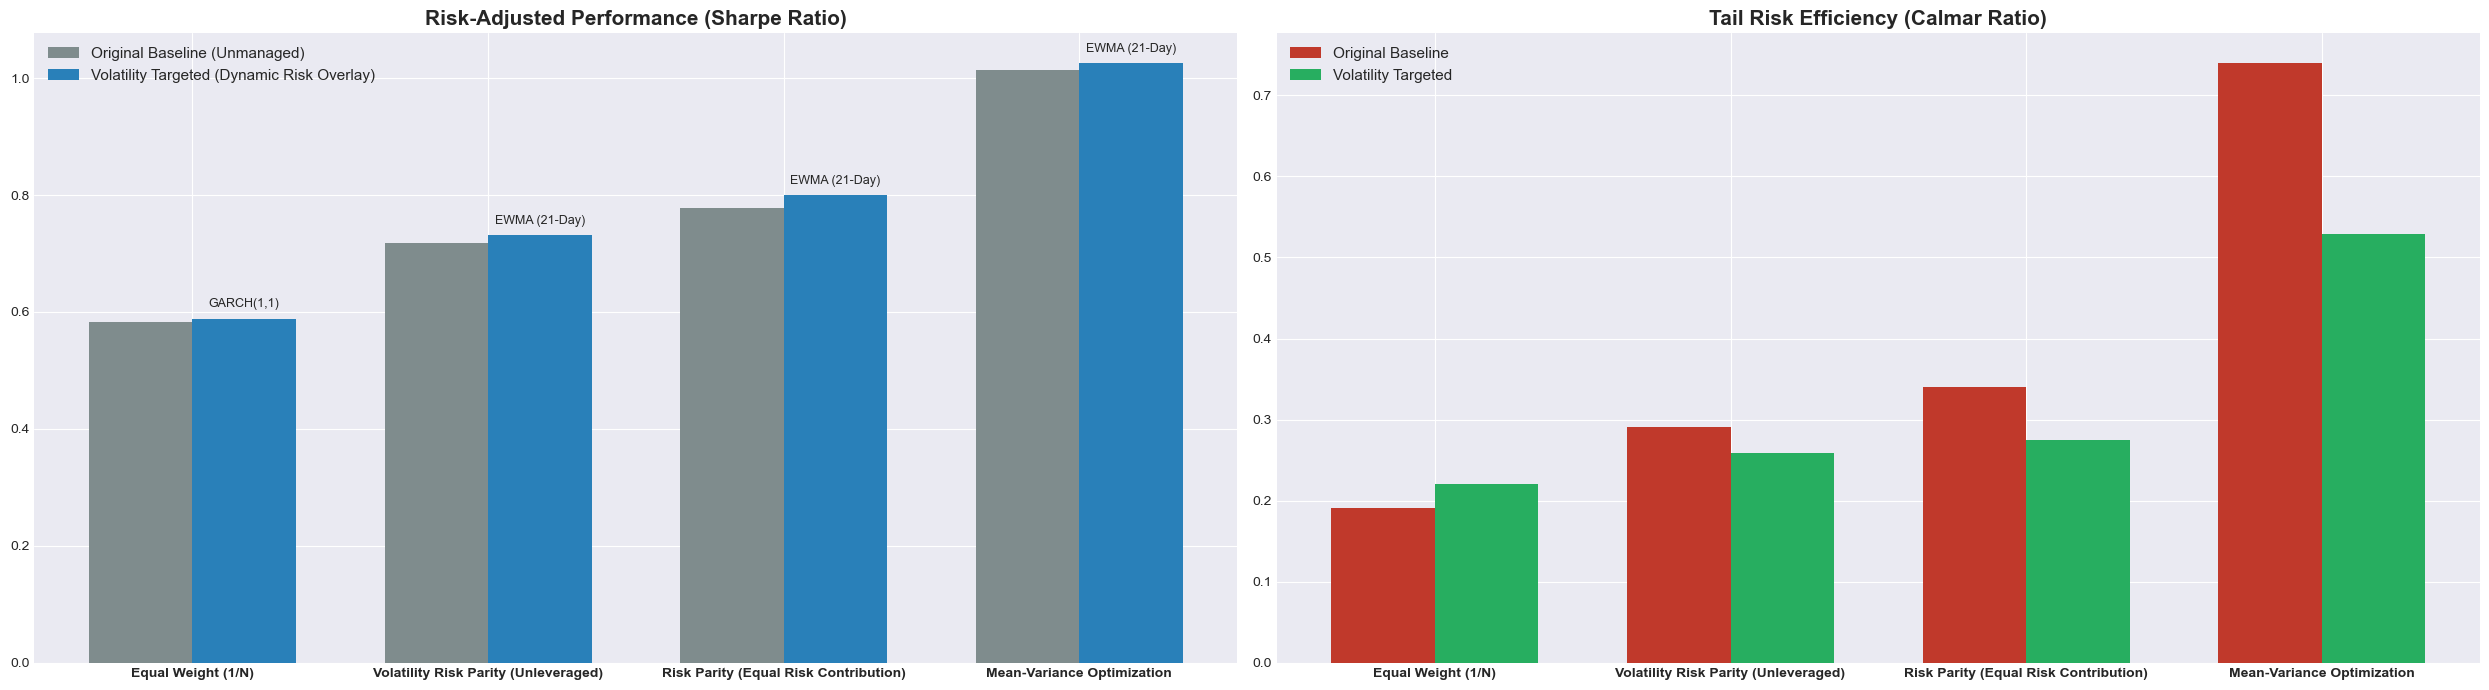

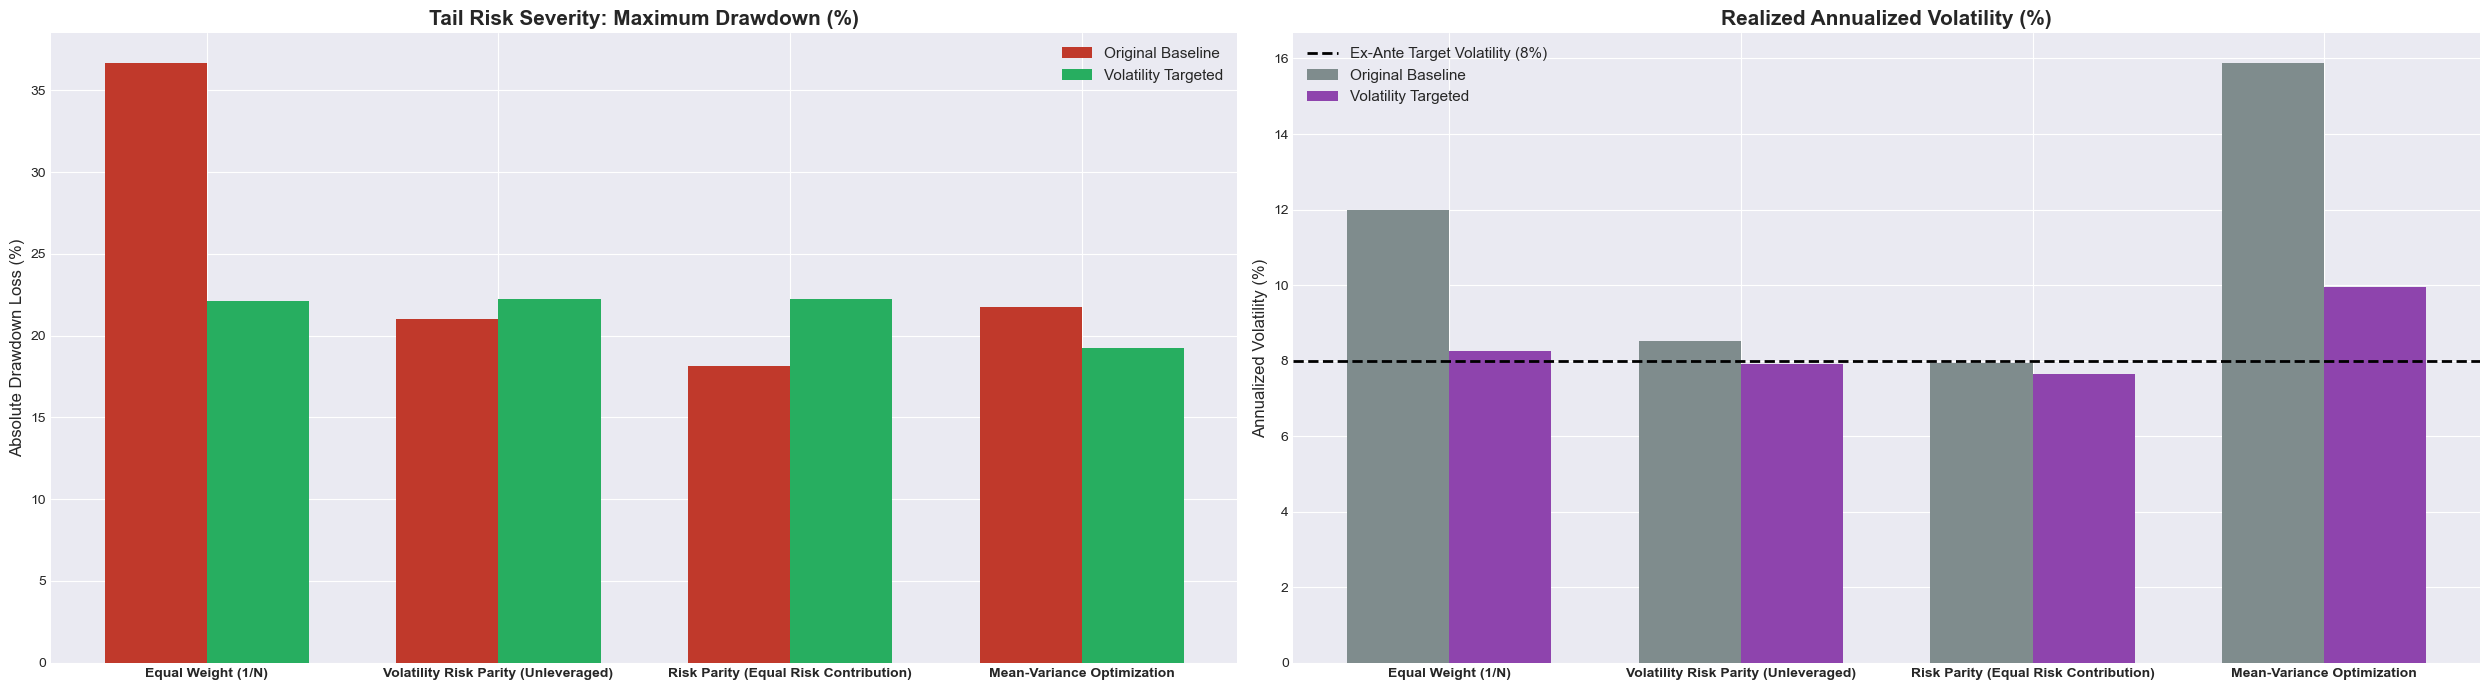

In [4]:
# ==============================================================================
# EXECUTION: BASELINES + VOLATILITY OVERLAYS
# ==============================================================================
import pandas as pd
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt
import os
import warnings
from pathlib import Path  # Added to support Path("Data")
warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# 1. DATA INGESTION & UNIVERSE DEFINITION
# ------------------------------------------------------------------------------

# Load the dataset
data_folder = Path("Data")
data_folder.mkdir(parents=True, exist_ok=True) # Ensure folder exists

csv_filename = data_folder / "Portfolio Asset Price Dataset.csv"
data = pd.read_csv(csv_filename, index_col=0, parse_dates=True)
daily_rets = data.pct_change().dropna()
assets_list = [c for c in daily_rets.columns if c != 'VFISX']
daily_rf = daily_rets['VFISX']

TARGET_VOL = 0.1  
CAP = 1.50         
THRESHOLD = 0.10   
mo_vol_tgt = TARGET_VOL / np.sqrt(12)

# Monthly Resampling
monthly_returns = data.resample('ME').last().pct_change().dropna()
rf_monthly = monthly_returns['VFISX']
excess_returns = monthly_returns.drop(columns=['VFISX']).sub(rf_monthly, axis=0)
risky_assets = excess_returns.columns
win = 36
oos_dates = excess_returns.index[win:]
n_assets = len(risky_assets)

# Labels
b_labels = {
    '1/N': 'Equal Weight (1/N)', 
    'VRP_Unlev': 'Volatility Risk Parity (Unleveraged)', 
    'ERC': 'Risk Parity (Equal Risk Contribution)', 
    'MVO': 'Mean-Variance Optimization'
}
v_labels = {'HIST_90': '90-Day Historical', 'EWMA': 'EWMA (21-Day)', 'GARCH': 'GARCH(1,1)', 'SV_Proxy': 'Stochastic Volatility'}
f_labels = {'weekly': 'Weekly', 'threshold': 'Threshold (10%)'}

# ------------------------------------------------------------------------------
# 2. MONTHLY WALK-FORWARD OPTIMIZATION (4 Baselines Only)
# ------------------------------------------------------------------------------
print("Calculating Base Strategy Weights...")
weights_dict = {k: pd.DataFrame(index=oos_dates, columns=risky_assets) for k in b_labels.keys()}

def erc_objective(w, cov):
    p_var = np.dot(w.T, np.dot(cov, w))
    risk_contrib = w * np.dot(cov, w)
    return np.sum(np.square(risk_contrib - p_var/n_assets)) * 1e9

for t in oos_dates:
    train = excess_returns.loc[:t].iloc[-win-1:-1]
    mu, cov, std = train.mean().values, train.cov().values, train.std().values
    
    # 1. 1/N
    weights_dict['1/N'].loc[t] = 1.0 / n_assets
    
    # 2. VRP Unleveraged
    w_afp = (1/std) / (1/std).sum()
    weights_dict['VRP_Unlev'].loc[t] = w_afp
    
    # 3. ERC
    res_erc = sco.minimize(erc_objective, np.ones(n_assets)/n_assets, args=(cov,), method='SLSQP', bounds=[(0,1)]*n_assets, constraints={'type':'eq','fun':lambda w: np.sum(w)-1})
    weights_dict['ERC'].loc[t] = res_erc.x if res_erc.success else w_afp
    
    # 4. MVO
    res_mvo = sco.minimize(lambda w: -np.dot(mu, w), np.ones(n_assets)/n_assets, method='SLSQP', bounds=[(-1,1)]*n_assets, constraints=[{'type':'eq','fun':lambda w: np.sum(w)-1}, {'type':'ineq','fun':lambda w: (mo_vol_tgt)**2 - np.dot(w.T, np.dot(cov, w))}])
    weights_dict['MVO'].loc[t] = res_mvo.x

# --- NEW SAVE BLOCK: RISKY ONLY BASE PROFILES ---
print(f"Exporting raw baseline weights to '{data_folder}'...")
for b_name, b_w_df in weights_dict.items():
    clean_b_name = b_name.replace('/', '_')
    # .dropna(how='all') ensures we don't save empty padding rows
    b_w_df.dropna(how='all').to_csv(data_folder / f'risky_only_baseline_weights_{clean_b_name}.csv')

# ------------------------------------------------------------------------------
# 3. OVERLAY & TURNOVER MATH
# ------------------------------------------------------------------------------
def get_vols_pure(returns):
    f = pd.DataFrame(index=returns.index)
    f['HIST_90'] = returns.rolling(90).std() * np.sqrt(252)
    f['EWMA'] = returns.ewm(span=21).std() * np.sqrt(252)
    
    om, al, be = 0.000001, 0.05, 0.94
    v_sq = [returns.var()]
    for r in returns: v_sq.append(om + al*(r**2) + be*v_sq[-1])
    f['GARCH'] = np.sqrt(pd.Series(v_sq[1:], index=returns.index)) * np.sqrt(252)
    f['SV_Proxy'] = np.sqrt(np.exp(np.log(returns.rolling(5).var()+1e-10).ewm(span=20).mean())) * np.sqrt(252)
    return f.shift(1).dropna()

def apply_overlay(p_rets, v_forecast, freq):
    exposure = (TARGET_VOL / v_forecast).clip(upper=CAP)
    if freq == 'weekly':
        exposure = exposure.resample('W-FRI').last().reindex(exposure.index).ffill()
    elif freq == 'threshold': 
        curr = exposure.iloc[0]; t_list = [curr]
        for v in exposure.iloc[1:]:
            if abs(v - curr) > THRESHOLD: curr = v
            t_list.append(curr)
        exposure = pd.Series(t_list, index=exposure.index)
    return (exposure * p_rets) + (1 - exposure) * daily_rf.loc[exposure.index], exposure

def calc_event_driven_turnover(target_weights_df, all_daily_returns, is_monthly_schedule=True):
    target_weights_df = target_weights_df.dropna()
    aligned_rets = all_daily_returns.loc[target_weights_df.index]
    
    targets_arr = target_weights_df.values
    rets_arr = aligned_rets.values
    dates = target_weights_df.index
    
    total_turnover = 0.0
    current_w = targets_arr[0].copy()
    
    for i in range(1, len(targets_arr)):
        target_changed = not np.allclose(targets_arr[i], targets_arr[i-1], atol=1e-5)
        month_changed = dates[i].month != dates[i-1].month
        
        if target_changed or (is_monthly_schedule and month_changed):
            total_turnover += np.sum(np.abs(targets_arr[i] - current_w)) / 2.0
            current_w = targets_arr[i].copy()
            
        current_w = current_w * (1.0 + rets_arr[i])
        port_ret = np.sum(current_w)
        if port_ret > 0:
            current_w = current_w / port_ret
            
    years = len(target_weights_df) / 252.0
    return total_turnover / years if years > 0 else 0.0

def get_advanced_metrics(strat_rets, rf_rets):
    ann_ret = (1 + strat_rets).prod()**(252/len(strat_rets)) - 1
    ann_vol = strat_rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = ((1+strat_rets).cumprod() / (1+strat_rets).cumprod().cummax() - 1).min()
    calmar = ann_ret / abs(max_dd) if max_dd < 0 else 0
    
    excess_rets = strat_rets - rf_rets.loc[strat_rets.index]
    downside_rets = excess_rets[excess_rets < 0]
    down_vol = downside_rets.std() * np.sqrt(252)
    
    # THE FIX: Removed the rogue np.sqrt(252) from the numerator
    sortino = ann_ret / down_vol if down_vol > 0 else 0 
    
    return ann_ret, ann_vol, max_dd, sharpe, calmar, sortino

# ------------------------------------------------------------------------------
# 4. EXECUTION & INSTITUTIONAL TEAR SHEET
# ------------------------------------------------------------------------------
print("\n" + "="*120)
print("PHASE 8: INSTITUTIONAL TEAR SHEET (ORIGINAL VS. VOLATILITY TARGETED)")
print("="*120)

full_rets_df = daily_rets[assets_list].copy()
full_rets_df['CASH'] = daily_rf
comp_data = []

for b_name, b_w_df in weights_dict.items():
    # --- Original Metrics ---
    w_start_mo = b_w_df.shift(1).dropna()
    m_ex = (w_start_mo * excess_returns.loc[w_start_mo.index, assets_list]).sum(axis=1)
    m_tot = m_ex + rf_monthly.loc[w_start_mo.index]
    
    orig_ret = (1 + m_tot).prod() ** (12 / len(m_tot)) - 1
    orig_vol = m_tot.std() * np.sqrt(12)
    orig_sharpe = orig_ret / orig_vol if orig_vol > 0 else 0
    orig_dd = ((1 + m_tot).cumprod() / (1 + m_tot).cumprod().cummax() - 1).min()
    orig_calmar = orig_ret / abs(orig_dd) if orig_dd < 0 else 0
    orig_sortino = orig_ret / (m_tot[m_tot < 0].std() * np.sqrt(12)) if len(m_tot[m_tot < 0]) > 0 else 0
    
    orig_tot_w = b_w_df.reindex(daily_rets.index).ffill().shift(1).dropna()
    orig_tot_w['CASH'] = 0.0
    orig_turnover = calc_event_driven_turnover(orig_tot_w, full_rets_df, is_monthly_schedule=True)

    # --- VT Metrics ---
    monthly_w = b_w_df.reindex(daily_rets.index).ffill()
    risky_rets = (monthly_w.shift(1).dropna() * daily_rets[assets_list]).sum(axis=1)
    v_f = get_vols_pure(risky_rets)
    
    best_sharpe = -999
    best_ov_data = {}
    best_exposure = None # Track optimal exposure
    
    for v_name in v_f.columns:
        for freq in ['weekly', 'threshold']:
            s_rets, exp = apply_overlay(risky_rets, v_f[v_name], freq)
            
            tot_w = monthly_w.loc[exp.index].mul(exp, axis=0).dropna()
            tot_w['CASH'] = 1.0 - exp
            vt_turnover = calc_event_driven_turnover(tot_w, full_rets_df, is_monthly_schedule=True)
            
            vt_ret, vt_vol, vt_dd, vt_sharpe, vt_calmar, vt_sortino = get_advanced_metrics(s_rets, daily_rf)
            
            if vt_sharpe > best_sharpe:
                best_sharpe = vt_sharpe
                best_exposure = exp.copy() # Store the winning risk/cash distribution
                best_ov_data = {
                    'Config': f"{v_labels[v_name]} | {f_labels[freq]}",
                    'VT Ret': vt_ret, 'VT Vol': vt_vol, 'VT Sharpe': vt_sharpe,
                    'VT Sortino': vt_sortino, 'VT Calmar': vt_calmar, 
                    'VT DD': vt_dd, 'VT Turn': vt_turnover
                }
                
    # --- NEW SAVE BLOCK: CASH VS RISK PROFILES ---
    if best_exposure is not None:
        clean_b_name = b_name.replace('/', '_')
        # Drop NaNs here to ensure we ONLY save dates where Volatility Targeting was actually active
        valid_exposure = best_exposure.dropna()
        overlay_allocation = pd.DataFrame(index=valid_exposure.index)
        overlay_allocation['Risky_Portfolio'] = valid_exposure
        overlay_allocation['CASH'] = 1.0 - valid_exposure
        overlay_allocation.to_csv(data_folder / f'overlay_split_{clean_b_name}.csv')
                
    comp_data.append({
        'Strategy': b_labels[b_name],
        'Winning Config': best_ov_data['Config'],
        'Orig Ret': orig_ret, 'VT Ret': best_ov_data['VT Ret'],
        'Orig Vol': orig_vol, 'VT Vol': best_ov_data['VT Vol'],
        'Orig Sharpe': orig_sharpe, 'VT Sharpe': best_ov_data['VT Sharpe'],
        'Orig Sortino': orig_sortino, 'VT Sortino': best_ov_data['VT Sortino'],
        'Orig Calmar': orig_calmar, 'VT Calmar': best_ov_data['VT Calmar'],
        'Orig DD': orig_dd, 'VT DD': best_ov_data['VT DD'],
        'Orig Turn': orig_turnover, 'VT Turn': best_ov_data['VT Turn']
    })

# Format and Print
comp_df = pd.DataFrame(comp_data)
fmt_df = comp_df.copy()
for col in ['Orig Ret', 'VT Ret', 'Orig Vol', 'VT Vol', 'Orig DD', 'VT DD', 'Orig Turn', 'VT Turn']: 
    fmt_df[col] = fmt_df[col].map('{:.2%}'.format)
for col in ['Orig Sharpe', 'VT Sharpe', 'Orig Sortino', 'VT Sortino', 'Orig Calmar', 'VT Calmar']: 
    fmt_df[col] = fmt_df[col].map('{:.2f}'.format)

print(fmt_df.to_string(index=False))

# ------------------------------------------------------------------------------
# 5. VISUALIZATIONS
# ------------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')
x = np.arange(len(comp_df['Strategy']))
width = 0.35

# Chart 1: Sharpe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 7))
ax1.bar(x - width/2, comp_df['Orig Sharpe'], width, label='Original Baseline (Unmanaged)', color='#7f8c8d')
ax1.bar(x + width/2, comp_df['VT Sharpe'], width, label='Volatility Targeted (Dynamic Risk Overlay)', color='#2980b9')
ax1.set_title('Risk-Adjusted Performance (Sharpe Ratio)', fontsize=15, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(comp_df['Strategy'], fontweight='bold')
ax1.legend(fontsize=11)

for i, v in enumerate(comp_df['VT Sharpe']):
    ax1.text(i + width/2, v + 0.02, comp_df.iloc[i]['Winning Config'].split(' | ')[0], ha='center', fontsize=9)

ax2.bar(x - width/2, comp_df['Orig Calmar'], width, label='Original Baseline', color='#c0392b')
ax2.bar(x + width/2, comp_df['VT Calmar'], width, label='Volatility Targeted', color='#27ae60')
ax2.set_title('Tail Risk Efficiency (Calmar Ratio)', fontsize=15, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(comp_df['Strategy'], fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
#plt.savefig('Baseline_Sharpe_and_Calmar_Comparison.png', dpi=300, bbox_inches='tight')
plt.show() 

# Chart 2: DD
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(25, 7))
ax3.bar(x - width/2, abs(comp_df['Orig DD'])*100, width, label='Original Baseline', color='#c0392b')
ax3.bar(x + width/2, abs(comp_df['VT DD'])*100, width, label='Volatility Targeted', color='#27ae60')
ax3.set_title('Tail Risk Severity: Maximum Drawdown (%)', fontsize=15, fontweight='bold')
ax3.set_ylabel('Absolute Drawdown Loss (%)', fontsize=12)
ax3.set_xticks(x); ax3.set_xticklabels(comp_df['Strategy'], fontweight='bold')
ax3.legend(fontsize=11)

ax4.bar(x - width/2, comp_df['Orig Vol']*100, width, label='Original Baseline', color='#7f8c8d')
ax4.bar(x + width/2, comp_df['VT Vol']*100, width, label='Volatility Targeted', color='#8e44ad')
ax4.set_title('Realized Annualized Volatility (%)', fontsize=15, fontweight='bold')
ax4.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax4.set_xticks(x); ax4.set_xticklabels(comp_df['Strategy'], fontweight='bold')
ax4.axhline(8.0, color='black', linestyle='--', linewidth=2, label='Ex-Ante Target Volatility (8%)')
ax4.legend(fontsize=11)

plt.tight_layout()
#plt.savefig('Baseline_Drawdown_and_Volatility_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()